# Mechanisms: Climate Conditions during ENSO-Induced Famines


In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import cftime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from scipy.stats import ttest_ind, mannwhitneyu

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         13,
    'axes.titlesize':    13,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   12,
    'axes.linewidth':    1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'pdf.fonttype':      42,
})

def _panel(ax, letter):
    ax.text(-0.08, 1.04, letter, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='bottom', ha='left')

def _polish(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


## Load data

In [2]:
prices = pd.read_csv('../processed data/price_2023_enso.csv')
famine = pd.read_csv('../processed data/famine_region_data.csv')
chron  = pd.read_csv('../analysis/output/data/fig2C_chronology_onsets.csv')

# â”€â”€ OWDA 
_coder   = xr.coders.CFDatetimeCoder(use_cftime=True)
owda     = xr.open_dataset('../data/owda.nc', decode_times=_coder)
owda     = owda.assign_coords(Year=owda.time).swap_dims({'time': 'Year'})
owda     = owda.sel(Year=slice(1500, 1800))
owda_eur = owda.sel(lat=slice(35, 70), lon=slice(-15, 35))

# â”€â”€ ModE-RA temperature 
xds_t = xr.open_dataset(
    '../data/ModE-RA_ensmean_temp2_anom_wrt_1901-2000_1421-2008_mon.nc',
    decode_times=_coder)
xds_t = xds_t.sel(time=slice('1500-01-01', '1800-12-31'))
xds_t_eur = xds_t.sel(latitude=slice(70, 35), longitude=slice(-15, 35))

# â”€â”€ ModE-RA precipitation (shift Nov/Dec to next year for NDJF) 
def _shift_dec(time_array):
    return [cftime.DatetimeGregorian(t.year+1, t.month, t.day)
            if t.month in [11, 12] else t for t in time_array]

xds_p = xr.open_dataset(
    '../data/ModE-RA_ensmean_totprec_anom_wrt_1901-2000_1421-2008_mon.nc',
    decode_times=_coder)
xds_p = xds_p.sel(time=slice('1500-01-01', '1800-12-31'))
xds_p = xds_p.assign_coords(time=('time', _shift_dec(xds_p.time.values)))
xds_p_eur = xds_p.sel(latitude=slice(70, 35), longitude=slice(-15, 35))

# â”€â”€ seasonal aggregates by year 
NDJF = [11, 12, 1, 2]
AMJJ = [4, 5, 6, 7]

t_ndjf = (xds_t_eur.sel(time=xds_t_eur.time.dt.month.isin(NDJF))
          .groupby('time.year').mean('time').rename({'year': 'Year'}))
t_amjj = (xds_t_eur.sel(time=xds_t_eur.time.dt.month.isin(AMJJ))
          .groupby('time.year').mean('time').rename({'year': 'Year'}))
p_amjj = (xds_p_eur.sel(time=xds_p_eur.time.dt.month.isin(AMJJ))
          .groupby('time.year').mean('time').rename({'year': 'Year'}))

print('OWDA:     ', dict(owda_eur.sizes))
print('T NDJF:   ', dict(t_ndjf.sizes))
print('T AMJJ:   ', dict(t_amjj.sizes))
print('P AMJJ:   ', dict(p_amjj.sizes))


OWDA:      {'lon': 94, 'lat': 70, 'Year': 301}
T NDJF:    {'Year': 301, 'latitude': 19, 'longitude': 27}
T AMJJ:    {'Year': 301, 'latitude': 19, 'longitude': 27}
P AMJJ:    {'Year': 301, 'latitude': 19, 'longitude': 27}


## Define famine-year lists

In [3]:
ce = famine[famine.Region == 'Central Europe']

lists = {
    'Counterfactual\n(ML)':   sorted(chron[(chron['Predicted_ML']==1) & (chron['Counterfactual_ML']==0)]['Year'].tolist()),
    'ENSO > 0':               sorted(ce[(ce.nino34 > 0.0) & (ce.Famine_start==1)]['Year'].tolist()),
    'ENSO > 0.5':             sorted(ce[(ce.nino34 > 0.5) & (ce.Famine_start==1)]['Year'].tolist()),
    'ENSO > 1':               sorted(ce[(ce.nino34 > 1.0) & (ce.Famine_start==1)]['Year'].tolist()),
}

for name, yrs in lists.items():
    print(f'{name.replace(chr(10)," "):<22} n={len(yrs):>2}  {yrs}')


Counterfactual (ML)    n= 9  [1530, 1565, 1594, 1620, 1635, 1651, 1661, 1719, 1770]
ENSO > 0               n=17  [1530, 1565, 1594, 1602, 1620, 1635, 1651, 1661, 1691, 1698, 1709, 1719, 1724, 1739, 1755, 1770, 1787]
ENSO > 0.5             n=11  [1530, 1565, 1594, 1620, 1635, 1651, 1661, 1719, 1755, 1770, 1787]
ENSO > 1               n= 6  [1565, 1594, 1620, 1635, 1651, 1661]


In [4]:
def make_composite(da, ef_years, dim='Year'):
    """Return (ef_mean, base_mean, anomaly, p_values) for a (Year, lat, lon) DataArray."""
    all_years   = da[dim].values.astype(int)
    matched_ef  = [y for y in ef_years  if y in all_years]
    matched_bas = [y for y in all_years if y not in ef_years]

    ef_mean  = da.sel({dim: matched_ef }).mean(dim=dim)
    bas_mean = da.sel({dim: matched_bas}).mean(dim=dim)
    anom     = ef_mean - bas_mean

    ef_3d  = da.sel({dim: matched_ef }).values   # (n_ef,  lat, lon)
    bas_3d = da.sel({dim: matched_bas}).values   # (n_bas, lat, lon)
    nlat, nlon = ef_3d.shape[1], ef_3d.shape[2]
    pvals = np.full((nlat, nlon), np.nan)
    for i in range(nlat):
        for j in range(nlon):
            e, b = ef_3d[:, i, j], bas_3d[:, i, j]
            me, mb = np.isfinite(e), np.isfinite(b)
            if me.sum() >= 3 and mb.sum() >= 3:
                _, pvals[i, j] = ttest_ind(e[me], b[mb], equal_var=False)

    return anom.values, pvals, len(matched_ef)


def prep_owda(ef_years):
    da = owda_eur['pdsi'].transpose('Year', 'lat', 'lon')
    anom, pvals, n = make_composite(da, ef_years, dim='Year')
    lon = owda_eur['lon'].values
    lat = owda_eur['lat'].values
    return anom, pvals, n, lon, lat


def prep_modERA(da_yr, ef_years, var):
    """da_yr has dims (Year, latitude, longitude)."""
    da = da_yr[var].transpose('Year', 'latitude', 'longitude')
    anom, pvals, n = make_composite(da, ef_years, dim='Year')
    lon = da_yr['longitude'].values
    lat = da_yr['latitude'].values
    return anom, pvals, n, lon, lat


print('Helper functions ready.')


Helper functions ready.


## Figure 1 Composite anomaly maps

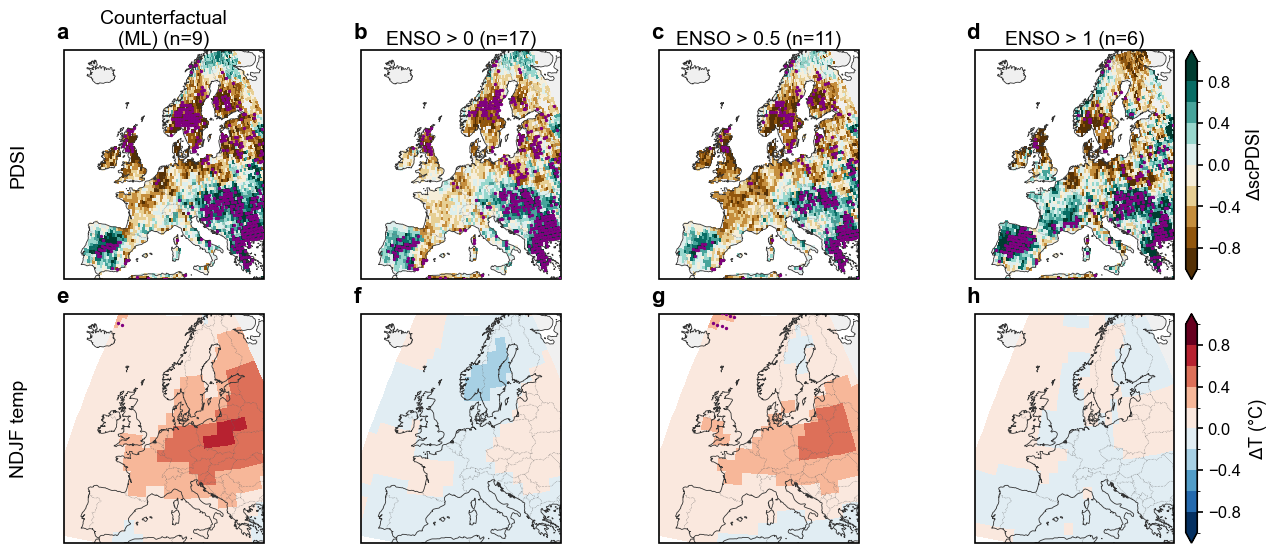

Dots = p < 0.10 (Welch t-test vs all non-famine years)


In [5]:
list_names  = list(lists.keys())
list_years  = list(lists.values())
n_cols = len(list_names)   # 4 columns

# rows: PDSI | NDJF temp
row_specs = [
    ('PDSI',      owda_eur, 'pdsi',  'BrBG',   (-1.0, 1.0), r'$\Delta$scPDSI'),
    ('NDJF temp', t_ndjf,  'temp2', 'RdBu_r', (-1.0, 1.0), r'$\Delta$T (°C)'),
]
n_rows = len(row_specs)

proj   = ccrs.EuroPP()
extent = [-12, 36, 35, 71]

fig = plt.figure(figsize=(3.8 * n_cols, 3.2 * n_rows))
gs  = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                        hspace=0.15, wspace=0.04)

panel_letter = ord('a')

for row_i, (row_label, ds, var, cmap_name, (vmin, vmax), cbar_label) in enumerate(row_specs):
    cmap   = plt.get_cmap(cmap_name)
    levels = np.linspace(vmin, vmax, 11)
    norm   = BoundaryNorm(levels, ncolors=cmap.N)

    is_owda = (var == 'pdsi')

    for col_i, (name, yrs) in enumerate(zip(list_names, list_years)):
        ax = fig.add_subplot(gs[row_i, col_i], projection=proj)

        if is_owda:
            anom, pvals, n, lon, lat = prep_owda(yrs)
        else:
            anom, pvals, n, lon, lat = prep_modERA(ds, yrs, var)

        lon2d, lat2d = np.meshgrid(lon, lat)

        im = ax.pcolormesh(lon2d, lat2d, anom,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap, norm=norm, shading='auto')
        sig = pvals <= 0.10
        ax.scatter(lon2d[sig], lat2d[sig], s=2, color='purple',
                   transform=ccrs.PlateCarree(), zorder=5)

        ax.coastlines(linewidth=0.6, color='#333333')
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4,
                       edgecolor='#666666')
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        ax.text(-0.04, 1.03, chr(panel_letter), transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='left')
        panel_letter += 1

        if row_i == 0:
            ax.set_title(name + ' (n=' + str(n) + ')', fontsize=14, pad=4)

        if col_i == 0:
            ax.text(-0.18, 0.5, row_label, transform=ax.transAxes,
                    fontsize=14, rotation=90, va='center', ha='right')

        if col_i == n_cols - 1:
            cb = plt.colorbar(im, ax=ax, orientation='vertical',
                              fraction=0.046, pad=0.04, extend='both')
            cb.set_label(cbar_label, fontsize=13)
            cb.ax.tick_params(labelsize=12)

plt.savefig('../analysis/output/figures/extended data/figED_mechanisms_maps.pdf',
            dpi=300, bbox_inches='tight')
plt.show()
print('Dots = p < 0.10 (Welch t-test vs all non-famine years)')

## Figure 2 Local climate at price-data cities

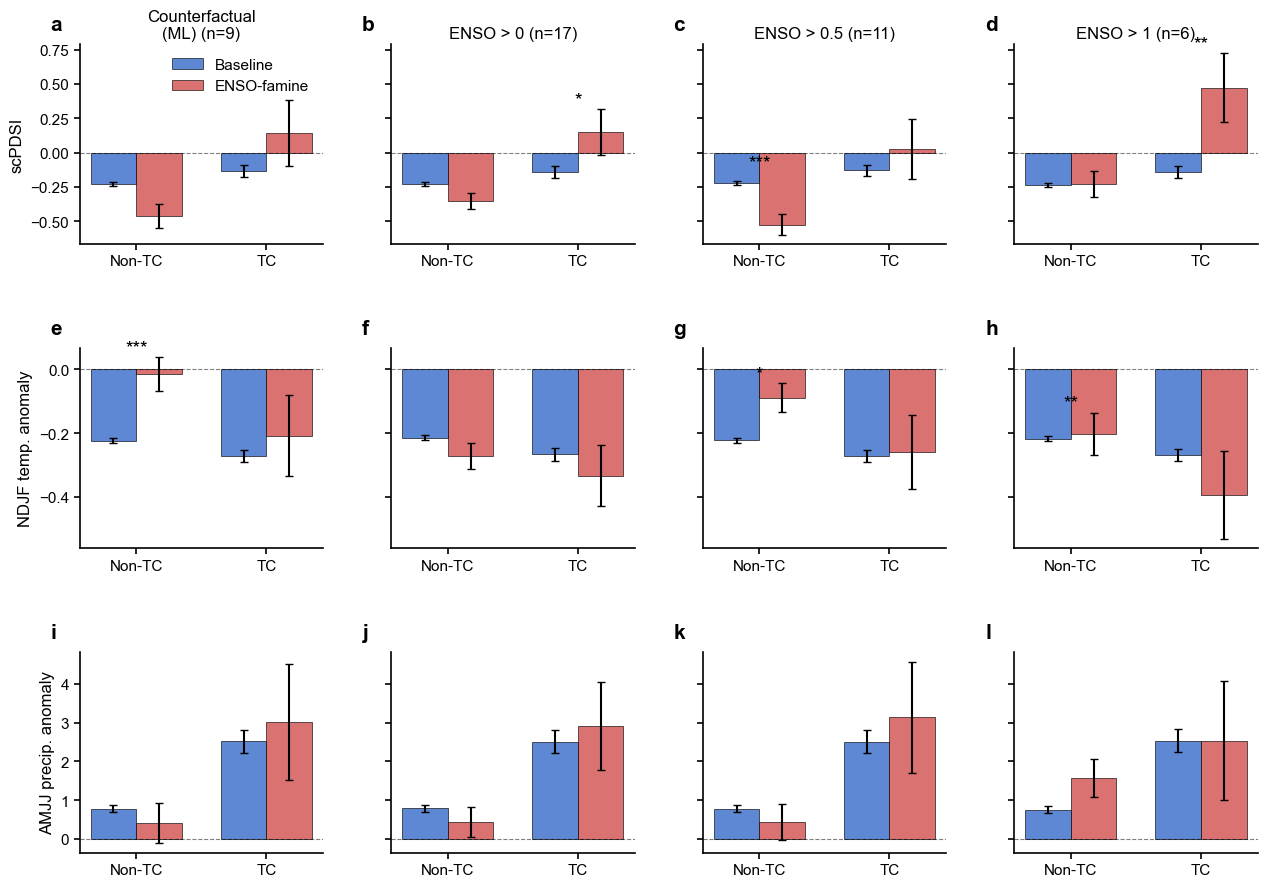

* p<0.10  ** p<0.05  *** p<0.01  (Mann-Whitney U, two-sided)


In [6]:
bar_vars = [
    ('PDSI',          'scPDSI'),
    ('temp_winter',   'NDJF temp. anomaly'),
    ('precip_summer', 'AMJJ precip. anomaly'),
]

groups        = ['Non-teleconnected', 'Teleconnected']
period_colors = {'Baseline': '#4878CF', 'ENSO-famine': '#D65F5F'}
x = np.arange(len(groups))
w = 0.35

n_brows = len(bar_vars)
n_bcols = len(list_names)

fig2, axes2 = plt.subplots(n_brows, n_bcols,
                            figsize=(3.8 * n_bcols, 3.5 * n_brows),
                            sharey='row')
fig2.subplots_adjust(hspace=0.52, wspace=0.28)

panel_letter = ord('a')

for row_i, (var, ylabel) in enumerate(bar_vars):
    for col_i, (name, yrs) in enumerate(zip(list_names, list_years)):
        ax = axes2[row_i, col_i]

        prices['enso_famine'] = prices['Year'].isin(yrs)
        prices['tc_label']    = prices['teleco_PDSI_10'].map(
            {1: 'Teleconnected', 0: 'Non-teleconnected'})

        for k, (period, color) in enumerate(period_colors.items()):
            vals, errs = [], []
            for g in groups:
                d = prices[(prices.tc_label == g) &
                           (prices.enso_famine == (period == 'ENSO-famine'))][var].dropna()
                vals.append(d.mean())
                errs.append(d.sem())
            offset = (k - 0.5) * w
            ax.bar(x + offset, vals, w, yerr=errs, capsize=3,
                   color=color, alpha=0.88, label=period,
                   edgecolor='black', linewidth=0.5)

        for i, g in enumerate(groups):
            ef = prices[(prices.tc_label == g) &  prices.enso_famine][var].dropna()
            bl = prices[(prices.tc_label == g) & ~prices.enso_famine][var].dropna()
            if len(ef) >= 3 and len(bl) >= 3:
                _, p = mannwhitneyu(ef, bl, alternative='two-sided')
                ymax = max(ef.mean(), bl.mean()) + max(ef.sem(), bl.sem())
                stars = ('***' if p<0.01 else '**' if p<0.05
                         else '*' if p<0.1 else '')
                ax.text(i, ymax, stars, ha='center', va='bottom', fontsize=14)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(['Non-TC', 'TC'], fontsize=11)
        ax.tick_params(axis='y', labelsize=11)

        # column header (top row only)
        if row_i == 0:
            ax.set_title(name.replace('\\n', '\n') + f' (n={len(yrs)})',
                         fontsize=12, pad=4)

        # row label (left column only)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=12)

        # legend (top-left panel only)
        if row_i == 0 and col_i == 0:
            ax.legend(frameon=False, fontsize=11)

        # panel letter
        ax.text(-0.12, 1.05, chr(panel_letter), transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='bottom', ha='left')
        panel_letter += 1

        _polish(ax)

plt.savefig('../figures/plots/mechanisms_bars.pdf',
            dpi=300, bbox_inches='tight')
plt.show()
print('* p<0.10  ** p<0.05  *** p<0.01  (Mann-Whitney U, two-sided)')


## Stats table

In [7]:
for name, yrs in lists.items():
    prices['enso_famine'] = prices['Year'].isin(yrs)
    prices['tc_label']    = prices['teleco_PDSI_10'].map(
        {1: 'Teleconnected', 0: 'Non-teleconnected'})
    label = name.replace('\n',' ')
    print(f'\nâ”€â”€ {label} (n={len(yrs)}) â”€â”€')
    print(f'{"Variable":<22} {"Non-TC: mean_ef":>15} {"mean_bl":>9} {"diff":>7} {"p":>6}'
          f'   {"TC: mean_ef":>12} {"mean_bl":>9} {"diff":>7} {"p":>6}')
    for var, vlabel in bar_vars:
        row = f'{vlabel:<22}'
        for tc in ['Non-teleconnected', 'Teleconnected']:
            ef = prices[(prices.tc_label==tc) &  prices.enso_famine][var].dropna()
            bl = prices[(prices.tc_label==tc) & ~prices.enso_famine][var].dropna()
            _, p = mannwhitneyu(ef, bl, alternative='two-sided')
            diff = ef.mean() - bl.mean()
            sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '+' if p<0.10 else ''
            row += f'  {ef.mean():>9.3f} {bl.mean():>9.3f} {diff:>+7.3f} {p:>5.3f}{sig:<3}'
        print(row)



â”€â”€ Counterfactual (ML) (n=9) â”€â”€
Variable               Non-TC: mean_ef   mean_bl    diff      p    TC: mean_ef   mean_bl    diff      p
scPDSI                     -0.460    -0.225  -0.234 0.203         0.147    -0.132  +0.279 0.216   
NDJF temp. anomaly         -0.014    -0.223  +0.209 0.003**      -0.208    -0.272  +0.065 0.931   
AMJJ precip. anomaly        0.414     0.783  -0.369 0.736         3.019     2.521  +0.498 0.860   

â”€â”€ ENSO > 0 (n=17) â”€â”€
Variable               Non-TC: mean_ef   mean_bl    diff      p    TC: mean_ef   mean_bl    diff      p
scPDSI                     -0.350    -0.225  -0.125 0.235         0.152    -0.140  +0.293 0.080+  
NDJF temp. anomaly         -0.271    -0.213  -0.058 0.148        -0.333    -0.266  -0.066 0.365   
AMJJ precip. anomaly        0.439     0.793  -0.353 0.509         2.906     2.514  +0.392 0.828   

â”€â”€ ENSO > 0.5 (n=11) â”€â”€
Variable               Non-TC: mean_ef   mean_bl    diff      p    TC: mean_ef   mean_bl    d

AMJJ precip. anomaly        1.578     0.755  +0.823 0.253         2.537     2.537  +0.001 0.965   
